<a href="https://colab.research.google.com/github/Bhargava-007/Machine-Learning-2-1/blob/main/Exp_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import os

print("Please upload your placement dataset CSV file.")
uploaded = files.upload()

# Get the uploaded filename automatically
FILE_NAME = next(iter(uploaded))

print(f"\nDataset uploaded successfully: {FILE_NAME}")
print(f"File size: {os.path.getsize(FILE_NAME) / (1024**2):.2f} MB")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

print("All libraries imported successfully.")

All libraries imported successfully.


In [ ]:
df = pd.read_csv(FILE_NAME)

print("Dataset loaded successfully!")
print(f"Number of rows    : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

Dataset loaded successfully!
Number of rows    : 50000
Number of columns : 32

First 5 rows:


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99



Column names:
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']


In [ ]:
FEATURES = [
    "CGPA",
    "AttendancePercent",
    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore",
    "ExtraCurricular",
]

TARGET = "Salary Package"

# Check that all required columns exist
required_columns = FEATURES + [TARGET]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"The following required columns are missing from the dataset:\n"
        f"{missing_columns}"
    )

data = df[required_columns].copy()

print("Selected features:")
for feature in FEATURES:
    print(f" - {feature}")

print(f"\nTarget: {TARGET}")

print(f"\nWorking dataset shape: {data.shape}")

Selected features:
 - CGPA
 - AttendancePercent
 - Internships
 - Projects
 - Workshops
 - Certifications
 - Publications
 - AptitudeTestScore
 - SoftSkillsRating
 - CodingTestScore
 - MockInterviewScore
 - ExtraCurricular

Target: Salary Package

Working dataset shape: (50000, 13)


In [ ]:
print("Missing values before imputation:\n")
print(data[FEATURES + [TARGET]].isnull().sum())

# Fill missing feature values with the median
data[FEATURES] = data[FEATURES].fillna(
    data[FEATURES].median()
)

# Remove rows where the target itself is missing
data = data.dropna(subset=[TARGET])

print("\nMissing values after preprocessing:\n")
print(data[FEATURES + [TARGET]].isnull().sum())

print(f"\nFinal dataset shape: {data.shape}")

Missing values before imputation:

CGPA                     0
AttendancePercent        0
Internships              0
Projects                 0
Workshops             4488
Certifications           0
Publications             0
AptitudeTestScore     4029
SoftSkillsRating      3526
CodingTestScore       2976
MockInterviewScore    4957
ExtraCurricular          0
Salary Package           0
dtype: int64

Missing values after preprocessing:

CGPA                  0
AttendancePercent     0
Internships           0
Projects              0
Workshops             0
Certifications        0
Publications          0
AptitudeTestScore     0
SoftSkillsRating      0
CodingTestScore       0
MockInterviewScore    0
ExtraCurricular       0
Salary Package        0
dtype: int64

Final dataset shape: (50000, 13)


In [ ]:
X = data[FEATURES].values

y = data[TARGET].values.reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX contains the 12 input features.")
print("y contains the Salary Package target.")

X shape: (50000, 12)
y shape: (50000, 1)

X contains the 12 input features.
y contains the Salary Package target.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

# Standardize features
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("\nFeature scaling completed.")
print("Scaler was fitted only on the training data.")

Training samples: 40000
Testing samples : 10000

Feature scaling completed.
Scaler was fitted only on the training data.


In [ ]:
n_samples, n_features = X_train_s.shape

# Add a column of 1s for the intercept/bias
X_train_b = np.hstack([
    np.ones((n_samples, 1)),
    X_train_s
])

X_test_b = np.hstack([
    np.ones((X_test_s.shape[0], 1)),
    X_test_s
])

print("Original number of features:", n_features)
print("Features after adding bias :", X_train_b.shape[1])

print("\nTraining matrix shape:", X_train_b.shape)
print("Testing matrix shape :", X_test_b.shape)

Original number of features: 12
Features after adding bias : 13

Training matrix shape: (40000, 13)
Testing matrix shape : (10000, 13)


In [ ]:
def compute_mse(X, y, theta):
    """
    Computes Mean Squared Error.

    MSE = average((prediction - actual)^2)
    """

    preds = X @ theta
    errors = preds - y

    return np.mean(errors ** 2)


print("MSE function created successfully.")

MSE function created successfully.


In [ ]:
def batch_gradient_descent(
    X,
    y,
    lr=0.05,
    n_epochs=500
):
    """
    Batch Gradient Descent for linear regression.

    Every update uses the entire training dataset.
    """

    m, n = X.shape

    # Initialize theta with zeros
    theta = np.zeros((n, 1))

    loss_history = []

    for epoch in range(n_epochs):

        # Predictions using all training samples
        preds = X @ theta

        # Prediction errors
        errors = preds - y

        # Gradient of MSE
        gradient = (2 / m) * (X.T @ errors)

        # Update parameters
        theta -= lr * gradient

        # Store training loss
        loss_history.append(
            compute_mse(X, y, theta)
        )

    return theta, loss_history


print("Batch Gradient Descent function created.")

Batch Gradient Descent function created.


In [ ]:
theta_gd, loss_history_gd = batch_gradient_descent(
    X_train_b,
    y_train,
    lr=0.05,
    n_epochs=500
)

# Test RMSE
rmse_gd = np.sqrt(
    compute_mse(
        X_test_b,
        y_test,
        theta_gd
    )
)

sk_model = LinearRegression()

# sklearn handles the intercept automatically
sk_model.fit(
    X_train_s,
    y_train
)

# Predictions
y_pred_sk = sk_model.predict(
    X_test_s
)

# Calculate RMSE
rmse_sklearn = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_sk
    )
)

print(f"[sklearn Linear Regression] Test RMSE = {rmse_sklearn:.4f}")

print(
    f"Difference (GD - sklearn) = "
    f"{rmse_gd - rmse_sklearn:.6f}"
)

[sklearn Linear Regression] Test RMSE = 4.4105
Difference (GD - sklearn) = 0.000000


In [ ]:
print("\n=== Batch GD vs sklearn ===")

print(f"Batch GD RMSE       : {rmse_gd:.4f}")
print(f"sklearn RMSE        : {rmse_sklearn:.4f}")
print(f"Absolute difference : {abs(rmse_gd - rmse_sklearn):.6f}")

if abs(rmse_gd - rmse_sklearn) < 0.01:
    print("\nBatch GD has converged very close to sklearn.")
else:
    print("\nThere is still a noticeable difference.")
    print("Consider increasing the number of epochs or adjusting the learning rate.")


=== Batch GD vs sklearn ===
Batch GD RMSE       : 4.4105
sklearn RMSE        : 4.4105
Absolute difference : 0.000000

Batch GD has converged very close to sklearn.


In [ ]:
def mini_batch_gradient_descent(
    X,
    y,
    lr=0.05,
    n_epochs=500,
    batch_size=256,
    seed=42
):
    """
    Mini-Batch Gradient Descent.

    Instead of using the entire dataset for one update,
    the training data is divided into smaller batches.
    """

    m, n = X.shape

    # Initialize parameters
    theta = np.zeros((n, 1))

    loss_history = []

    # Reproducible random generator
    rng = np.random.default_rng(seed)

    for epoch in range(n_epochs):

        # Shuffle training examples
        indices = rng.permutation(m)

        X_shuffled = X[indices]
        y_shuffled = y[indices]

        # Process mini-batches
        for start in range(0, m, batch_size):

            end = start + batch_size

            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            # Predictions
            preds = X_batch @ theta

            # Errors
            errors = preds - y_batch

            # Gradient using only current mini-batch
            gradient = (
                2 / X_batch.shape[0]
            ) * (X_batch.T @ errors)

            # Update theta
            theta -= lr * gradient

        # Calculate loss on the FULL training dataset
        loss_history.append(
            compute_mse(X, y, theta)
        )

    return theta, loss_history


print("Mini-Batch Gradient Descent function created.")

Mini-Batch Gradient Descent function created.


In [ ]:
theta_mb, loss_history_mb = mini_batch_gradient_descent(
    X_train_b,
    y_train,
    lr=0.05,
    n_epochs=500,
    batch_size=256,
    seed=42
)

# Test RMSE
rmse_mb = np.sqrt(
    compute_mse(
        X_test_b,
        y_test,
        theta_mb
    )
)

print(f"[Mini-Batch GD] Test RMSE = {rmse_mb:.4f}")

[Mini-Batch GD] Test RMSE = 4.4190


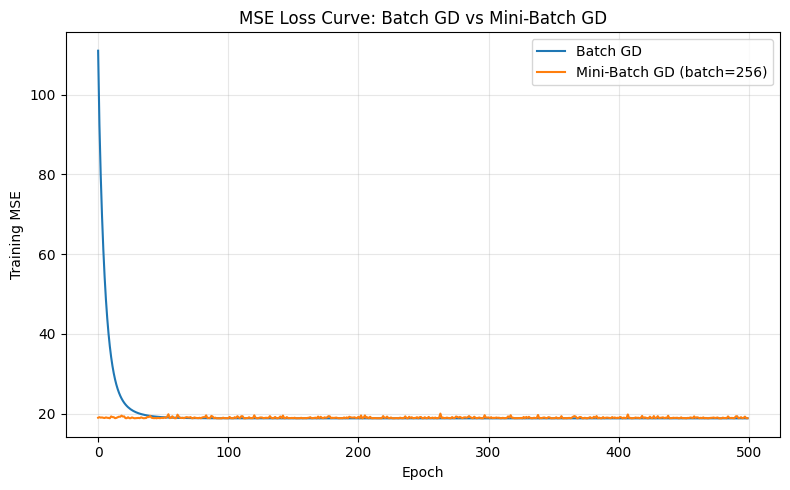

Loss curve saved as: loss_curve.png


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    loss_history_gd,
    label="Batch GD"
)

plt.plot(
    loss_history_mb,
    label="Mini-Batch GD (batch=256)"
)

plt.xlabel("Epoch")
plt.ylabel("Training MSE")

plt.title(
    "MSE Loss Curve: Batch GD vs Mini-Batch GD"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "loss_curve.png",
    dpi=150
)

plt.show()

print("Loss curve saved as: loss_curve.png")

In [ ]:
print("\n" + "=" * 55)
print("                 RMSE COMPARISON")
print("=" * 55)

print(f"{'Method':<25}{'Test RMSE':>15}")
print("-" * 55)

print(f"{'Batch GD':<25}{rmse_gd:>15.4f}")
print(f"{'Mini-Batch GD':<25}{rmse_mb:>15.4f}")
print(f"{'sklearn LinearRegression':<25}{rmse_sklearn:>15.4f}")

print("=" * 55)


                 RMSE COMPARISON
Method                         Test RMSE
-------------------------------------------------------
Batch GD                          4.4105
Mini-Batch GD                     4.4190
sklearn LinearRegression          4.4105
